#### LOADING DATA FILE AND LIBRARIES

In [3]:
import pandas as pd
import numpy as np

In [4]:
acc = pd.read_csv("master_acc.csv", encoding="latin-1", low_memory=False,index_col="accident_id")

In [5]:
for col in acc.columns:
    print(f"\nColumn: {col}")
    print("Unique count:", acc[col].nunique())
    print("Sample unique values:", acc[col].dropna().unique()[:10])


Column: collision_label
Unique count: 7
Sample unique values: ['Side_two_vehicles' 'Other_collision' 'Rear_end_two_vehicles'
 'Frontal_two_vehicles' 'No_collision' 'Multiple_three_plus'
 'Chain_three_plus']

Column: is_weekend
Unique count: 2
Sample unique values: [False  True]

Column: season
Unique count: 4
Sample unique values: ['Winter' 'Spring' 'Summer' 'Autumn']

Column: surface_condition_label
Unique count: 4
Sample unique values: ['Normal' 'Wet' 'other' 'Unknown']

Column: manoeuvre_label
Unique count: 9
Sample unique values: ['Straight_ahead' 'Roundabout' 'other' 'Avoiding_obstacle' 'Interaction'
 'Park/Start/Stop' 'Reversing' 'Loss_of_control' 'Turning']

Column: sex_label
Unique count: 2
Sample unique values: ['Female' 'Male']

Column: user_category_label
Unique count: 4
Sample unique values: ['Driver' 'Pedestrian' 'Passenger' 'other']

Column: injury_severity_label
Unique count: 4
Sample unique values: ['Uninjured' 'Injured_Hospitalized' 'Killed' 'Injured_Slight']

Column:

In [6]:
### Fixing Nans in target
print(acc["injury_severity_label"].isna().sum())

# Drop rows with missing target
acc = acc.dropna(subset=["injury_severity_label"])

print("Remaining rows:", acc.shape[0])


21357
Remaining rows: 1412032


### MODELLING PREPROCESSING

#### TRAIN/TEST SPLIT

In [7]:
from sklearn.model_selection import train_test_split

X = acc.drop(columns=["injury_severity_label"])
y = acc["injury_severity_label"]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)
print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (1129625, 26) Test size: (282407, 26)


#### Handle Remaining NaNs

In [8]:
from sklearn.impute import SimpleImputer

# Numeric columns
numeric_cols = ["age", "lane_width"]

num_imputer = SimpleImputer(strategy="median")
X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])

# Categorical columns
categorical_cols = [
    "collision_label", "surface_condition_label", "manoeuvre_label",
    "sex_label", "user_category_label", "seat_position_label", "journey_purpose_label",
    "vehicle_group", "impact_group", "road_group", "weather_group",
    "day_of_week", "hour_group", "season"
]

cat_imputer = SimpleImputer(strategy="most_frequent")
X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])

# Check again for NaNs
print("Remaining NaNs in train:", X_train.isna().sum().sum())
print("Remaining NaNs in test:", X_test.isna().sum().sum())

Remaining NaNs in train: 1591
Remaining NaNs in test: 398


In [9]:
# Show which columns still have NaNs
print("Train NaNs per column:\n", X_train.isna().sum()[X_train.isna().sum() > 0])
print("\nTest NaNs per column:\n", X_test.isna().sum()[X_test.isna().sum() > 0])

Train NaNs per column:
 age_group    1591
dtype: int64

Test NaNs per column:
 age_group    398
dtype: int64


In [10]:
# Ensure dtype is categorical
X_train["age_group"] = X_train["age_group"].astype("category")
X_test["age_group"] = X_test["age_group"].astype("category")

# Add "Unknown" to categories if not already present
if "Unknown" not in X_train["age_group"].cat.categories:
    X_train["age_group"] = X_train["age_group"].cat.add_categories(["Unknown"])
    X_test["age_group"] = X_test["age_group"].cat.add_categories(["Unknown"])

# Fill NaNs with "Unknown"
X_train["age_group"] = X_train["age_group"].fillna("Unknown")
X_test["age_group"] = X_test["age_group"].fillna("Unknown")

# Final check
print("Remaining NaNs in train:", X_train.isna().sum().sum())
print("Remaining NaNs in test:", X_test.isna().sum().sum())

Remaining NaNs in train: 0
Remaining NaNs in test: 0


#### Encoding Categorical Features

In [11]:
from sklearn.preprocessing import OneHotEncoder

# Define categorical columns
categorical_cols = [
    "collision_label", "surface_condition_label", "manoeuvre_label",
    "sex_label", "user_category_label", "seat_position_label", "journey_purpose_label",
    "vehicle_group", "impact_group", "road_group", "weather_group",
    "day_of_week", "hour_group", "season", "age_group"
]

# Initialize encoder
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Fit on train, transform both train and test
X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

print("Encoded train shape:", X_train_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

Encoded train shape: (1129625, 74)
Encoded test shape: (282407, 74)


#### Scale Numeric Features

In [12]:
from sklearn.preprocessing import StandardScaler

# Numeric columns
numeric_cols = ["age", "lane_width"]

scaler = StandardScaler()

X_train_num_scaled = scaler.fit_transform(X_train[numeric_cols])
X_test_num_scaled = scaler.transform(X_test[numeric_cols])

print("Scaled train shape:", X_train_num_scaled.shape)
print("Scaled test shape:", X_test_num_scaled.shape)

Scaled train shape: (1129625, 2)
Scaled test shape: (282407, 2)


#### Combine All Features

In [13]:
import numpy as np
#
# Binary columns
binary_cols = [
    "is_weekend", "is_holiday", "seatbelt_used", "helmet_used",
    "any_protection_used", "protection_effective",
    "motorcycle_side_impact", "is_night", "is_urban"
]

# Combine all parts
X_train_final = np.hstack([
    X_train_num_scaled,          # numeric
    X_train_encoded,         # categorical
    X_train[binary_cols].values  # binary flags
])

X_test_final = np.hstack([
    X_test_num_scaled,
    X_test_encoded,
    X_test[binary_cols].values
])

print("Final train shape:", X_train_final.shape)
print("Final test shape:", X_test_final.shape)

Final train shape: (1129625, 85)
Final test shape: (282407, 85)


#### Encoding Target Labels 

In [14]:
# Encoding Target Labels (y_train & y_test)

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

In [15]:
#Recovering feature names

# Get categorical feature names from the encoder
categorical_feature_names = encoder.get_feature_names_out(categorical_cols)

# Numeric + binary names
numeric_feature_names = numeric_cols
binary_feature_names = binary_cols

# Combine all names
feature_names = list(numeric_feature_names) + list(categorical_feature_names) + list(binary_feature_names)

# Replace whitespace with underscores
feature_names = [name.replace(" ", "_") for name in feature_names]

# Wrap X_train_lgbm into a DataFrame with names
import pandas as pd
X_train_lgbm = pd.DataFrame(X_train_final, columns=feature_names)
X_test_lgbm = pd.DataFrame(X_test_final, columns=feature_names)

### MODEL - LEVEL OPTIMIZATION - LGBM - BINARY CLASSIFICATION

#### Training LightGBM (binary)

In [16]:
# y_train_enc and y_test_enc already exist from LabelEncoder

# Define severe classes (0 and 2)
severe_classes = [0, 2]

# Create binary labels
y_train_bin = np.where(np.isin(y_train_enc, severe_classes), 1, 0)
y_test_bin = np.where(np.isin(y_test_enc, severe_classes), 1, 0)

# Use ALL features first for baseline
X_train_bin = pd.DataFrame(X_train_final, columns=feature_names)
X_test_bin  = pd.DataFrame(X_test_final, columns=feature_names)

# Check distribution
print("Train binary distribution:", np.bincount(y_train_bin))
print("Test binary distribution:", np.bincount(y_test_bin))

Train binary distribution: [885955 243670]
Test binary distribution: [221489  60918]


In [17]:
list(zip(y_train[:20], y_train_enc[:20], y_train_bin[:20]))

[('Uninjured', np.int64(3), np.int64(0)),
 ('Injured_Hospitalized', np.int64(0), np.int64(1)),
 ('Uninjured', np.int64(3), np.int64(0)),
 ('Killed', np.int64(2), np.int64(1)),
 ('Uninjured', np.int64(3), np.int64(0)),
 ('Uninjured', np.int64(3), np.int64(0)),
 ('Injured_Slight', np.int64(1), np.int64(0)),
 ('Injured_Hospitalized', np.int64(0), np.int64(1)),
 ('Injured_Slight', np.int64(1), np.int64(0)),
 ('Injured_Hospitalized', np.int64(0), np.int64(1)),
 ('Uninjured', np.int64(3), np.int64(0)),
 ('Uninjured', np.int64(3), np.int64(0)),
 ('Uninjured', np.int64(3), np.int64(0)),
 ('Uninjured', np.int64(3), np.int64(0)),
 ('Injured_Hospitalized', np.int64(0), np.int64(1)),
 ('Uninjured', np.int64(3), np.int64(0)),
 ('Uninjured', np.int64(3), np.int64(0)),
 ('Injured_Slight', np.int64(1), np.int64(0)),
 ('Injured_Hospitalized', np.int64(0), np.int64(1)),
 ('Uninjured', np.int64(3), np.int64(0))]

In [18]:
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    roc_auc_score, classification_report
)

# -----------------------------
# 1. Simple LightGBM model (defaults)
# -----------------------------
model = LGBMClassifier(random_state=42)
model.fit(X_train_bin, y_train_bin)

# -----------------------------
# 2. Predictions
# -----------------------------
y_pred_prob = model.predict_proba(X_test_bin)[:, 1]
y_pred = (y_pred_prob >= 0.5).astype(int)

# -----------------------------
# 3. Evaluation
# -----------------------------
acc = accuracy_score(y_test_bin, y_pred)
f1 = f1_score(y_test_bin, y_pred)
bal_acc = balanced_accuracy_score(y_test_bin, y_pred)
roc = roc_auc_score(y_test_bin, y_pred_prob)

print("=== Simple LightGBM Binary Classification (Defaults) ===")
print(f"Accuracy:          {acc:.4f}")
print(f"F1 (Severe=1):     {f1:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"ROC-AUC:           {roc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_bin, y_pred, target_names=["Not Severe", "Severe"]))

[LightGBM] [Info] Number of positive: 243670, number of negative: 885955
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030373 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 519
[LightGBM] [Info] Number of data points in the train set: 1129625, number of used features: 85
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.215709 -> initscore=-1.290851
[LightGBM] [Info] Start training from score -1.290851
=== Simple LightGBM Binary Classification (Defaults) ===
Accuracy:          0.8241
F1 (Severe=1):     0.4852
Balanced Accuracy: 0.6647
ROC-AUC:           0.8337

Classification Report:
              precision    recall  f1-score   support

  Not Severe       0.85      0.95      0.89    221489
      Severe       0.66      0.38      0.49     60918

    accuracy                           0.82    282407
   macro avg       0.75      0.66   

In [19]:
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    roc_auc_score, classification_report
)

# -----------------------------
# 1. Simple LightGBM model (defaults)
# -----------------------------
model = LGBMClassifier(
    objective='binary',
    class_weight='balanced',   # handle imbalance
    random_state=42
)

model.fit(X_train_bin, y_train_bin)

# -----------------------------
# 2. Predictions
# -----------------------------
y_pred_prob = model.predict_proba(X_test_bin)[:, 1]
y_pred = (y_pred_prob >= 0.5).astype(int)

# -----------------------------
# 3. Evaluation
# -----------------------------
acc = accuracy_score(y_test_bin, y_pred)
f1 = f1_score(y_test_bin, y_pred)
bal_acc = balanced_accuracy_score(y_test_bin, y_pred)
roc = roc_auc_score(y_test_bin, y_pred_prob)

print("=== Simple LightGBM Binary Classification (Defaults) ===")
print(f"Accuracy:          {acc:.4f}")
print(f"F1 (Severe=1):     {f1:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"ROC-AUC:           {roc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_bin, y_pred, target_names=["Not Severe", "Severe"]))

[LightGBM] [Info] Number of positive: 243670, number of negative: 885955
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031747 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 519
[LightGBM] [Info] Number of data points in the train set: 1129625, number of used features: 85
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
=== Simple LightGBM Binary Classification (Defaults) ===
Accuracy:          0.7394
F1 (Severe=1):     0.5657
Balanced Accuracy: 0.7566
ROC-AUC:           0.8339

Classification Report:
              precision    recall  f1-score   support

  Not Severe       0.93      0.73      0.81    221489
      Severe       0.44      0.79      0.57     60918

    accuracy                           0.74    282407
   macro avg       0.68      0.76   

### Binary SMOTE Pipeline

In [20]:
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    roc_auc_score, classification_report
)

# -----------------------------
# 1. Apply SMOTE to binary labels
# -----------------------------
smote_bin = SMOTE(
    sampling_strategy='auto',   # oversample Severe until balanced
    random_state=42
)

X_train_bin_sm, y_train_bin_sm = smote_bin.fit_resample(X_train_bin, y_train_bin)

print("Before SMOTE:", np.bincount(y_train_bin))
print("After SMOTE:", np.bincount(y_train_bin_sm))

# -----------------------------
# 2. Train LightGBM (simple defaults)
# -----------------------------
model_bin_sm = LGBMClassifier(
    objective='binary',
    random_state=42
)

model_bin_sm.fit(X_train_bin_sm, y_train_bin_sm)

# -----------------------------
# 3. Predictions
# -----------------------------
y_pred_prob_sm = model_bin_sm.predict_proba(X_test_bin)[:, 1]
y_pred_sm = (y_pred_prob_sm >= 0.5).astype(int)

# -----------------------------
# 4. Evaluation
# -----------------------------
acc = accuracy_score(y_test_bin, y_pred_sm)
f1 = f1_score(y_test_bin, y_pred_sm)
bal_acc = balanced_accuracy_score(y_test_bin, y_pred_sm)
roc = roc_auc_score(y_test_bin, y_pred_prob_sm)

print("\n=== LightGBM + SMOTE (Binary Severe vs Not Severe) ===")
print(f"Accuracy:          {acc:.4f}")
print(f"F1 (Severe=1):     {f1:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"ROC-AUC:           {roc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_bin, y_pred_sm, target_names=["Not Severe", "Severe"]))

Before SMOTE: [885955 243670]
After SMOTE: [885955 885955]
[LightGBM] [Info] Number of positive: 885955, number of negative: 885955
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.133489 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20794
[LightGBM] [Info] Number of data points in the train set: 1771910, number of used features: 85
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

=== LightGBM + SMOTE (Binary Severe vs Not Severe) ===
Accuracy:          0.8161
F1 (Severe=1):     0.5192
Balanced Accuracy: 0.6871
ROC-AUC:           0.8262

Classification Report:
              precision    recall  f1-score   support

  Not Severe       0.86      0.91      0.89    221489
      Severe       0.60      0.46      0.52     60918

    accuracy                           0.82    282407
   macro avg       0.73      0.

In [21]:
from imblearn.over_sampling import BorderlineSMOTE
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    roc_auc_score, classification_report
)
import numpy as np

# ---------------------------------------------------------
# 1. Apply BorderlineSMOTE to binary labels
# ---------------------------------------------------------
bsmote = BorderlineSMOTE(kind='borderline-1', random_state=42)
X_train_bsm, y_train_bsm = bsmote.fit_resample(X_train_bin, y_train_bin)

print("Before BorderlineSMOTE:", np.bincount(y_train_bin))
print("After BorderlineSMOTE:", np.bincount(y_train_bsm))

# ---------------------------------------------------------
# 2. Train LightGBM (simple defaults)
# ---------------------------------------------------------
model_bsm = LGBMClassifier(
    objective='binary',
    random_state=42
)

model_bsm.fit(X_train_bsm, y_train_bsm)

# ---------------------------------------------------------
# 3. Predictions
# ---------------------------------------------------------
y_prob_bsm = model_bsm.predict_proba(X_test_bin)[:, 1]
y_pred_bsm = (y_prob_bsm >= 0.5).astype(int)

# ---------------------------------------------------------
# 4. Evaluation
# ---------------------------------------------------------
acc = accuracy_score(y_test_bin, y_pred_bsm)
f1 = f1_score(y_test_bin, y_pred_bsm)
bal_acc = balanced_accuracy_score(y_test_bin, y_pred_bsm)
roc = roc_auc_score(y_test_bin, y_prob_bsm)

print("\n=== LightGBM + BorderlineSMOTE (Binary Severe vs Not Severe) ===")
print(f"Accuracy:          {acc:.4f}")
print(f"F1 (Severe=1):     {f1:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"ROC-AUC:           {roc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_bin, y_pred_bsm, target_names=["Not Severe", "Severe"]))

Before BorderlineSMOTE: [885955 243670]
After BorderlineSMOTE: [885955 885955]
[LightGBM] [Info] Number of positive: 885955, number of negative: 885955
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.158813 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20811
[LightGBM] [Info] Number of data points in the train set: 1771910, number of used features: 85
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

=== LightGBM + BorderlineSMOTE (Binary Severe vs Not Severe) ===
Accuracy:          0.8137
F1 (Severe=1):     0.5169
Balanced Accuracy: 0.6862
ROC-AUC:           0.8247

Classification Report:
              precision    recall  f1-score   support

  Not Severe       0.86      0.91      0.88    221489
      Severe       0.59      0.46      0.52     60918

    accuracy                           0.81    282407
 

#### PCA Projections (PCA Projection for Original vs Normal SMOTE vs BorderlineSMOTE Data)

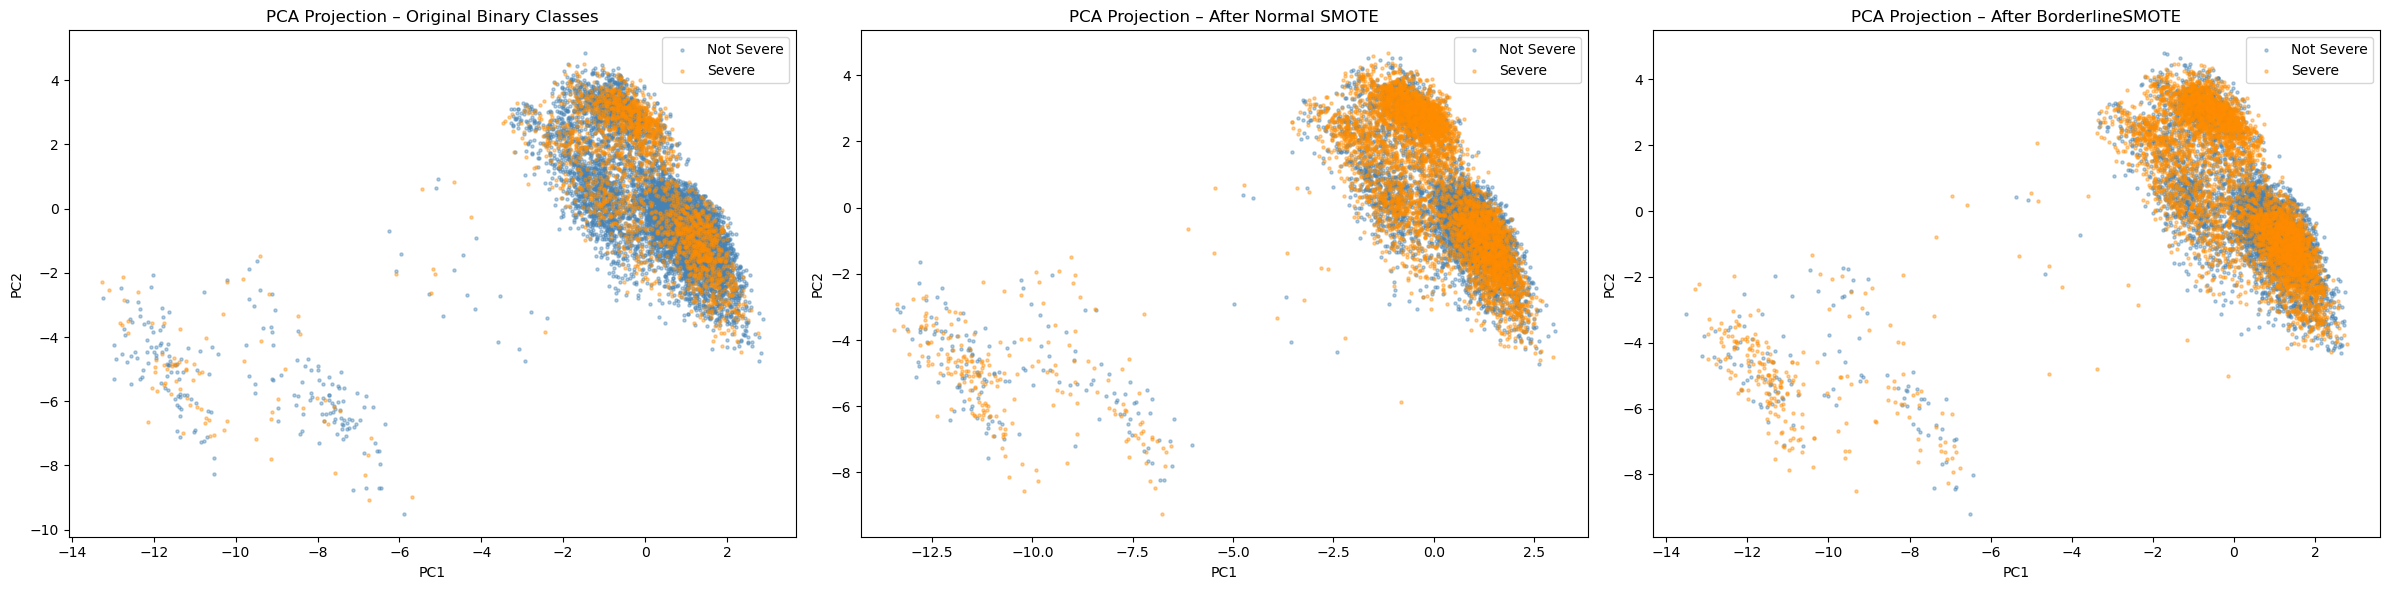

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ---------------------------------------------------------
# 1. Scale all datasets using the same scaler
# ---------------------------------------------------------
scaler = StandardScaler()
X_train_bin_scaled = scaler.fit_transform(X_train_bin)
X_train_smote_scaled = scaler.transform(X_train_bin_sm)
X_train_bsm_scaled = scaler.transform(X_train_bsm)

# ---------------------------------------------------------
# 2. Fit PCA on original scaled data
# ---------------------------------------------------------
pca = PCA(n_components=2, random_state=42)
X_pca_orig = pca.fit_transform(X_train_bin_scaled)
X_pca_smote = pca.transform(X_train_smote_scaled)
X_pca_bsm = pca.transform(X_train_bsm_scaled)

# ---------------------------------------------------------
# 3. Sample 10,000 points from each dataset
# ---------------------------------------------------------
np.random.seed(42)

idx_orig = np.random.choice(len(X_pca_orig), size=10000, replace=False)
idx_smote = np.random.choice(len(X_pca_smote), size=10000, replace=False)
idx_bsm = np.random.choice(len(X_pca_bsm), size=10000, replace=False)

X_pca_orig_sample = X_pca_orig[idx_orig]
y_orig_sample = y_train_bin[idx_orig]

X_pca_smote_sample = X_pca_smote[idx_smote]
y_smote_sample = y_train_bin_sm[idx_smote]

X_pca_bsm_sample = X_pca_bsm[idx_bsm]
y_bsm_sample = y_train_bsm[idx_bsm]

# ---------------------------------------------------------
# 4. Plot side-by-side PCA projections
# ---------------------------------------------------------
plt.figure(figsize=(24, 6))

# -------- Original --------
plt.subplot(1, 3, 1)
plt.scatter(X_pca_orig_sample[y_orig_sample == 0, 0], X_pca_orig_sample[y_orig_sample == 0, 1],
            s=5, alpha=0.4, label="Not Severe", color="steelblue")
plt.scatter(X_pca_orig_sample[y_orig_sample == 1, 0], X_pca_orig_sample[y_orig_sample == 1, 1],
            s=5, alpha=0.4, label="Severe", color="darkorange")
plt.title("PCA Projection – Original Binary Classes")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()

# -------- Normal SMOTE --------
plt.subplot(1, 3, 2)
plt.scatter(X_pca_smote_sample[y_smote_sample == 0, 0], X_pca_smote_sample[y_smote_sample == 0, 1],
            s=5, alpha=0.4, label="Not Severe", color="steelblue")
plt.scatter(X_pca_smote_sample[y_smote_sample == 1, 0], X_pca_smote_sample[y_smote_sample == 1, 1],
            s=5, alpha=0.4, label="Severe", color="darkorange")
plt.title("PCA Projection – After Normal SMOTE")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()

# -------- BorderlineSMOTE --------
plt.subplot(1, 3, 3)
plt.scatter(X_pca_bsm_sample[y_bsm_sample == 0, 0], X_pca_bsm_sample[y_bsm_sample == 0, 1],
            s=5, alpha=0.4, label="Not Severe", color="steelblue")
plt.scatter(X_pca_bsm_sample[y_bsm_sample == 1, 0], X_pca_bsm_sample[y_bsm_sample == 1, 1],
            s=5, alpha=0.4, label="Severe", color="darkorange")
plt.title("PCA Projection – After BorderlineSMOTE")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()

plt.tight_layout()
plt.show()

#### SHAP analysis for binary model

c:\Users\NeoM\anaconda3\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


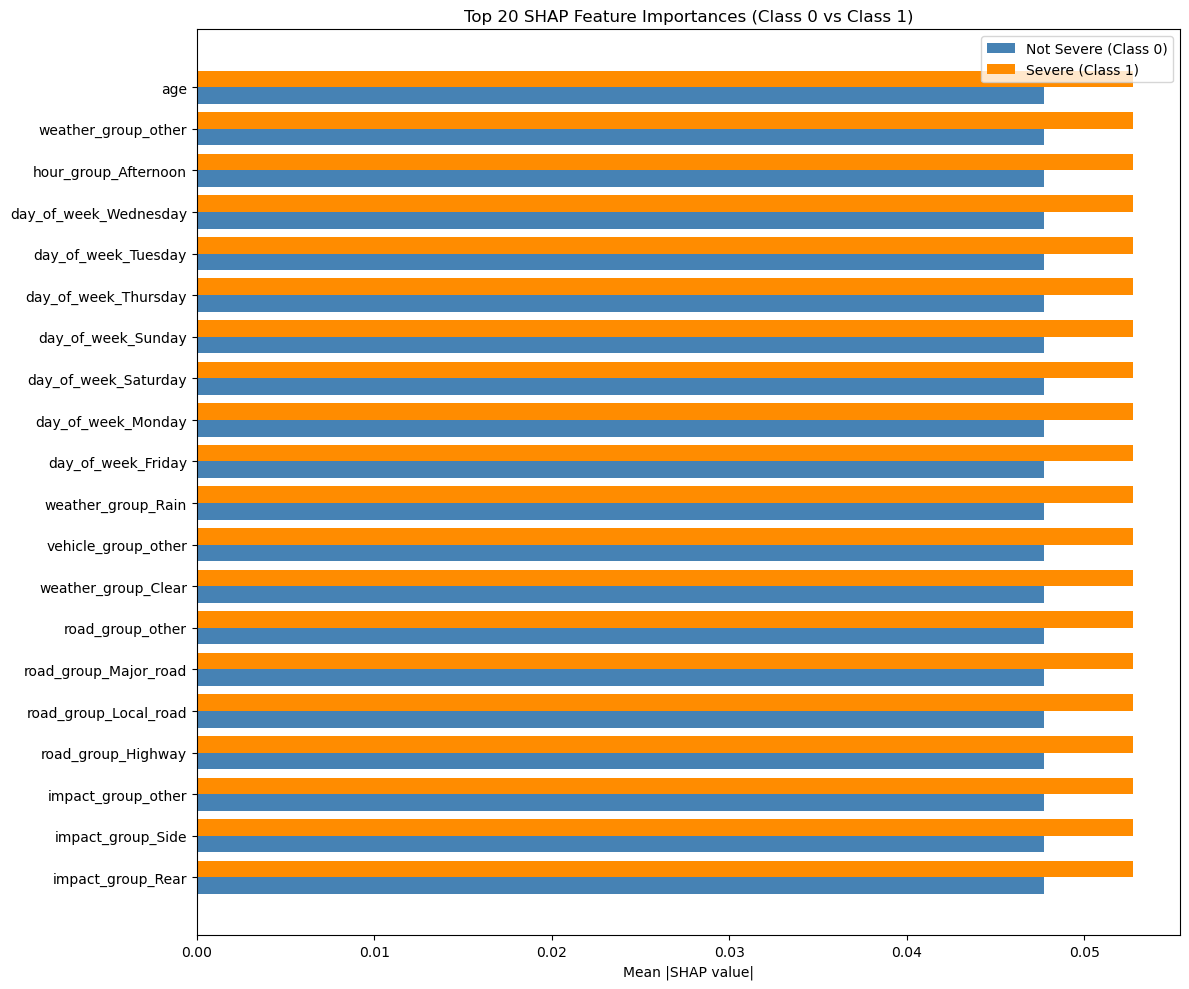

In [23]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Compute SHAP values for the BorderlineSMOTE model
# ---------------------------------------------------------
explainer = shap.TreeExplainer(model_bsm)
shap_values = explainer.shap_values(X_test_bin)

# shap_values is a list: [class0_values, class1_values]
shap_class0 = np.abs(shap_values[0]).mean(axis=0)
shap_class1 = np.abs(shap_values[1]).mean(axis=0)

# ---------------------------------------------------------
# 2. Build dataframe for plotting
# ---------------------------------------------------------
df = pd.DataFrame({
    "feature": X_test_bin.columns,
    "class0": shap_class0,
    "class1": shap_class1
})

df["total"] = df["class0"] + df["class1"]

# Select top 20 features
df_top = df.sort_values("total", ascending=False).head(20)

# Reverse for nicer plotting (top at top)
df_top = df_top.iloc[::-1]

# ---------------------------------------------------------
# 3. Plot side-by-side horizontal bars
# ---------------------------------------------------------
plt.figure(figsize=(12, 10))

bar_width = 0.4
y = np.arange(len(df_top))

plt.barh(y - bar_width/2, df_top["class0"], height=bar_width,
         color="steelblue", label="Not Severe (Class 0)")

plt.barh(y + bar_width/2, df_top["class1"], height=bar_width,
         color="darkorange", label="Severe (Class 1)")

plt.yticks(y, df_top["feature"])
plt.xlabel("Mean |SHAP value|")
plt.title("Top 20 SHAP Feature Importances (Class 0 vs Class 1)")
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
import shap
import numpy as np
import pandas as pd

# Compute SHAP values
explainer = shap.TreeExplainer(model_bsm)
shap_values = explainer.shap_values(X_test_bin)

# Mean absolute SHAP values for each class
shap_class0 = np.abs(shap_values[0]).mean(axis=0)
shap_class1 = np.abs(shap_values[1]).mean(axis=0)

# Build dataframe
df = pd.DataFrame({
    "feature": X_test_bin.columns,
    "class0": shap_class0,
    "class1": shap_class1
})

df["total"] = df["class0"] + df["class1"]

# Top 40 features
top40_features = df.sort_values("total", ascending=False).head(40)["feature"].tolist()

print("Top 40 SHAP features:")
print(top40_features)

Top 40 SHAP features:
['age', 'weather_group_other', 'hour_group_Afternoon', 'day_of_week_Wednesday', 'day_of_week_Tuesday', 'day_of_week_Thursday', 'day_of_week_Sunday', 'day_of_week_Saturday', 'day_of_week_Monday', 'day_of_week_Friday', 'weather_group_Rain', 'vehicle_group_other', 'weather_group_Clear', 'road_group_other', 'road_group_Major_road', 'road_group_Local_road', 'road_group_Highway', 'impact_group_other', 'impact_group_Side', 'impact_group_Rear', 'hour_group_Evening', 'hour_group_Morning', 'hour_group_Night', 'season_Autumn', 'is_night', 'motorcycle_side_impact', 'protection_effective', 'any_protection_used', 'helmet_used', 'seatbelt_used', 'is_holiday', 'is_weekend', 'age_group_Young_Adult', 'age_group_Unknown', 'age_group_Senior', 'age_group_Middle_Aged', 'age_group_Child', 'age_group_Adult', 'season_Winter', 'season_Summer']


c:\Users\NeoM\anaconda3\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [25]:
#Subseting your training + test data
X_train_bsm_top40 = X_train_bsm[top40_features]
X_test_bin_top40 = X_test_bin[top40_features]

#Retrain LightGBM on reduced features
from lightgbm import LGBMClassifier

model_bsm_top40 = LGBMClassifier(
    objective='binary',
    random_state=42
)
model_bsm_top40.fit(X_train_bsm_top40, y_train_bsm)

#Evaluate the reduced‑feature model
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, roc_auc_score, classification_report

y_prob_top40 = model_bsm_top40.predict_proba(X_test_bin_top40)[:, 1]
y_pred_top40 = (y_prob_top40 >= 0.5).astype(int)

acc = accuracy_score(y_test_bin, y_pred_top40)
f1 = f1_score(y_test_bin, y_pred_top40)
bal_acc = balanced_accuracy_score(y_test_bin, y_pred_top40)
roc = roc_auc_score(y_test_bin, y_prob_top40)

print("\n=== LightGBM + BorderlineSMOTE + Top 40 SHAP Features ===")
print(f"Accuracy:          {acc:.4f}")
print(f"F1 (Severe=1):     {f1:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"ROC-AUC:           {roc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_bin, y_pred_top40, target_names=['Not Severe', 'Severe']))


[LightGBM] [Info] Number of positive: 885955, number of negative: 885955
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.076880 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10001
[LightGBM] [Info] Number of data points in the train set: 1771910, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

=== LightGBM + BorderlineSMOTE + Top 40 SHAP Features ===
Accuracy:          0.7858
F1 (Severe=1):     0.4129
Balanced Accuracy: 0.6275
ROC-AUC:           0.7594

Classification Report:
              precision    recall  f1-score   support

  Not Severe       0.84      0.91      0.87    221489
      Severe       0.50      0.35      0.41     60918

    accuracy                           0.79    282407
   macro avg       0.67      0.63      0.64    282407
weighted avg       0.76      0.79

### VISUALIZATIONS

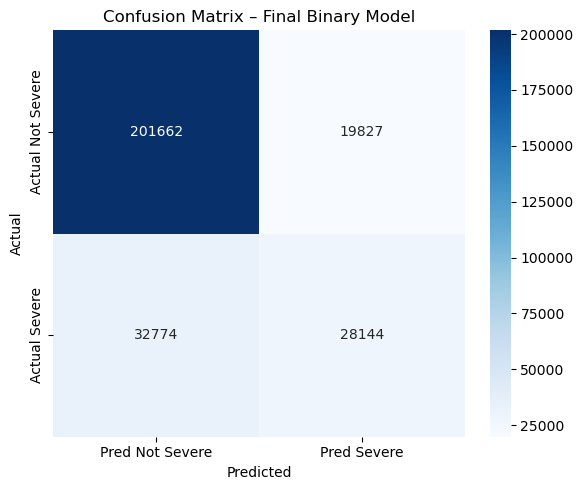

In [26]:
# Confusion Matrix Heatmap (Final Model)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_bin, y_pred_bsm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Not Severe", "Pred Severe"],
            yticklabels=["Actual Not Severe", "Actual Severe"])
plt.title("Confusion Matrix – Final Binary Model")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

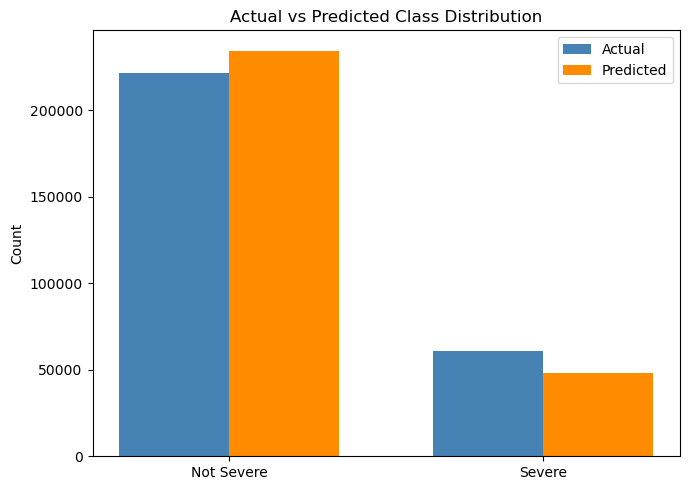

In [27]:
import matplotlib.pyplot as plt
import numpy as np

actual_counts = np.bincount(y_test_bin)
pred_counts = np.bincount(y_pred_bsm)

labels = ["Not Severe", "Severe"]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7,5))
plt.bar(x - width/2, actual_counts, width, label="Actual", color="steelblue")
plt.bar(x + width/2, pred_counts, width, label="Predicted", color="darkorange")

plt.xticks(x, labels)
plt.ylabel("Count")
plt.title("Actual vs Predicted Class Distribution")
plt.legend()
plt.tight_layout()
plt.show()